# `geom_pointdensity()`

In [1]:
import numpy as np
import pandas as pd

from lets_plot import *


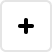
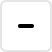
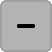
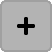
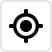
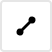
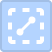
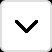
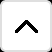
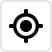
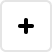
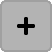
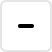
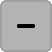
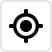
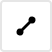
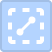
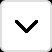
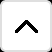
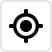

In [2]:
LetsPlot.setup_html()

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/refs/heads/master/data/mpg.csv")
print(df.shape)
df.head()

(234, 12)


,Unnamed: 0,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,1,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,2,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,3,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,4,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,5,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


## Default Plot

In [4]:
ggplot(df, aes("cty", "hwy")) + geom_pointdensity()

## Aesthetics

In [5]:
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity(aes(alpha="..density.."), color="black") + \
    ggtitle("Custom color and alpha")

In [6]:
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity(aes(fill="..density.."), color="black", shape=21) + \
    ggtitle("Custom shape, color and fill")

In [7]:
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity(shape=17, angle=90) + \
    ggtitle("Custom shape and angle")

In [8]:
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity(aes(size="..density.."), color="black", alpha=.2) + \
    scale_size(trans="reverse") + \
    ggtitle("Custom size, color and alpha")

In [9]:
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity(shape=1, stroke=2, alpha=.5) + \
    ggtitle("Custom shape, stroke and alpha")

## Parameters

### Own Parameters

In [10]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggtitle("Default adjust"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity(adjust=10) + ggtitle("adjust=10"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity(adjust=.1) + ggtitle("adjust=0.1"),
], ncol=2)

### Standard Parameters

In [11]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggtitle("Default position"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity(position='jitter') + ggtitle("position='jitter'"),
])

In [12]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggtitle("Default show_legend"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity(show_legend=False) + ggtitle("show_legend=False"),
])

In [13]:
gggrid([
    ggplot(df, aes(alpha="..density..")) + \
        geom_pointdensity(aes("cty", "hwy")) + \
        ggtitle("Default inherit_aes"),
    ggplot(df, aes(alpha="..density..")) + \
        geom_pointdensity(aes("cty", "hwy"), inherit_aes=False) + \
        ggtitle("inherit_aes=False"),
])

In [14]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggtitle("Default manual_key"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity(manual_key="point density") + ggtitle('manual_key="point density"'),
])

In [15]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + \
        geom_pointdensity() + \
        coord_cartesian(xlim=[7, 37], ylim=[10, 46]) + \
        ggtitle("Default sampling"),
    ggplot(df, aes("cty", "hwy")) + \
        geom_pointdensity(sampling=sampling_random(20, seed=42)) + \
        coord_cartesian(xlim=[7, 37], ylim=[10, 46]) + \
        ggtitle("sampling=sampling_random(20, seed=42)"),
])

In [16]:
pointdensity_tooltips = layer_tooltips().title("point density")\
                                        .line("position|(^x, ^y)")\
                                        .line("@|@..density..")\
                                        .line("count|@..count..")\
                                        .line("scaled|@..scaled..")
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity(tooltips=pointdensity_tooltips) + \
    ggtitle("Custom tooltips")

In [17]:
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity(aes(paint_a="..density..", paint_b="..density.."), color_by='paint_a', fill_by='paint_b', shape=21) + \
    scale_brewer('paint_a', palette="Reds") + \
    scale_brewer('paint_b', palette="Oranges") + \
    ggtitle("Use of color_by and fill_by")

## Stat

### `stat='identity'`

In [18]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggtitle("Default stat"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity(stat='identity') + ggtitle("stat='identity'"),
])

### `'pointdensity'` Stat

In [19]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + geom_bin2d() + ggtitle("geom_bin2d() with default stat"),
    ggplot(df, aes("cty", "hwy")) + geom_bin2d(aes(fill="..density.."), stat='pointdensity') + ggtitle("geom_bin2d(stat='pointdensity')"),
])

## Interaction with other layers

### `ggmarginal()`

In [20]:
ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggmarginal("tr", layer=geom_density())

### `ggtb()`

In [21]:
ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggtb()

### Facets

In [22]:
ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + facet_grid(x="year")

### Coordinate Systems

In [23]:
gggrid([
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + ggtitle("Default coordinate system"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + coord_flip() + ggtitle("coord_flip()"),
    ggplot(df, aes("cty", "hwy")) + geom_pointdensity() + coord_polar() + ggtitle("coord_polar()"),
])

### Themes

In [24]:
ggplot(df, aes("cty", "hwy")) + \
    geom_pointdensity() + \
    scale_color_brewer(palette="Oranges") + \
    theme_minimal() + \
    theme(legend_position='bottom') + \
    flavor_darcula()

## Tests

In [25]:
tests = [
    {
        'title': "Empty data",
        'data': {
            'x': [],
            'y': [],
        }
    },
    {
        'title': "One element",
        'data': {
            'x': [0],
            'y': [0],
        }
    },
    {
        'title': "NaN's in data",
        'data': {
            'x': [0, np.nan, None, 1, 2],
            'y': [0, 3, 4, np.nan, None],
        }
    },
]

gggrid([
    ggplot(t['data'], aes('x', 'y')) + \
        geom_pointdensity() + \
        ggtitle(t['title'])
    for t in tests
], ncol=2)

In [26]:
def get_mapping(var):
    if var is None:
        return aes('x', 'y')
    else:
        return aes('x', 'y', color=var, fill=var)

p_working = lambda var: ggplot({'x': [0], 'y': [0]}, get_mapping(var))

p_no_data = lambda var: ggplot(mapping=aes('x', 'y', color=var, fill=var)) if var is not None else ggplot(mapping=aes('x', 'y'))

p_empty = lambda var: ggplot({'x': [], 'y': []}, get_mapping(var))

p_facet_nan = lambda var: ggplot({'x': [0, np.nan], 'y': [0, 0], 'g': ["A", "B"]}, get_mapping(var)) + facet_grid(x='g')

p_facet_cross = lambda var: ggplot({'x': [0, 0], 'y': [0, 0], 'g1': ["A", "B"], 'g2': ["C", "D"]}, get_mapping(var)) + facet_grid(x='g1', y='g2')

p_group = ggplot({'x': [0, np.nan], 'y': [0, 0], 'g': ["A", "B"]}, aes('x', 'y', color='g', fill='g'))

p_nan = lambda var: ggplot({'x': [np.nan], 'y': [np.nan]}, get_mapping(var))

p_lim = lambda var: ggplot({'x': [0], 'y': [0]}, get_mapping(var)) + xlim(1, 2)

gggrid([
    p_working("..density..") + geom_pointdensity(),
    p_no_data("..density..") + geom_pointdensity(),
    p_empty("..density..") + geom_pointdensity(),
    p_facet_nan("..density..") + geom_pointdensity(),
    p_facet_cross("..density..") + geom_pointdensity(),
    p_group + geom_pointdensity(),
    p_nan("..density..") + geom_pointdensity(),
    p_lim("..density..") + geom_pointdensity(),
], ncol=2)